# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 43     |  |
| :-------------|:-------------|
| Tobias van Bavel| 6436404 |
 Oscar Pouw|6409806|
| Amélie Honig| 6361064|

| Planning Groep: 43     |Tijdstip / Tijdspanne  |
|---|---|
| Planning maken | 11:15 |
| Sanity Checks | 11:30 |
| Criteria opgesteld | 12:00 |
| Sub-ontwerpstap Synthese | 12:30 |
| Sub-ontwerpstap Simulatie | 14:00 |
| Eerste kalibratie meting gedaan| 14:30 |
| Sub-ontwerpstap conclusie | 15:15 |
| Aantonen leerdoelen en inleveren BS | 16:00 |
| Evalueren groepswerk | 16:30 |
| Pauze 1| 12:30 - 13:30 |
| Pauze 2| 15:15 - 15:30 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

Schets Ideeen:
![Alt](schetsenjuist.jpg "schets student")
 

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Hall Sensor | Airpod afstand detectie | Moet alleen AirPods detecteren, geen andere apparaten; Moet pas melding geven wanneer de AirPods zich op ca 500 meter van de eigenaar bevinden; Moet minimaal net zo weerbestendig als AirPods zijn. Met verschil merken tussen magnetisch veld van de aarde (50 microtesla), en airpods/digitale apparaten(75microesla).Hij moet dus tussen de 25 en 100 microtesla nauwkeurig kunnen meten (1 microtesla))|
|LDR | Thuisverlichting sensor | Als het buiten donker is, onder 5000 lux, moeten de lichten aan; Verschil weten tussen zonlicht en lamplicht, zodat de lampen aan blijven (verschil tussen 32000 en 5000 lux meten met een nauwkeurigheid van 100 lux.); Waterdicht IP5|
|Force sensor | AirPod sensor | Moet reageren op hele lichte bewegingen: tussen 0.4 en 1 Newton; Moet waterbestendig zijn, zodat het ook met bv natte vingers gebruikt kan worden, IP3 water resistant; Foutmarge reactie moet heel klein zijn, max 0.1N, zodat de AirPod niet reageert als je het apparaat bijvoorbeeld oppakt of per ongeluk aanraakt.|



Groep 43 heeft gekozen voor sensor force sensor. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.

Rechts in de foto is het circuit getekend. 
Links is de meetopstelling te zien: we gaan de sensor vlak op de weegschaal leggen en ervoor zorgen dat het gewicht constant is. Daarna gaan we filmen, met de laptop en dus de Arduino resultaten op de achtergrond, om terug te kijken op film wat de precieze gegevens waren.

Ook gaan we de sensor in een bakje water leggen, om te testen of deze daarna nogsteeds goed zijn werk doet.

![Alt](schetsPlanJuist.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
We gaan de kracht die we op de druksensor uitvoeren steeds veranderen.
2. Over welk bereik ga je deze variabelen veranderen?
We gaan het tussen 0.4N en 5N veranderen.
3. Wat ga je allemaal meten?
We gaan de massa meten met een weegschaal en daarmee de kracht en de bytes. 
Daarna gaan we meten of de sensor überhaupt werkt onder water.
4. Hoeveel metingen ga je doen?
We gaan 5 metingen doen.
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
We zouden met deze keuzes wel kunnen beantwoorden of het sensor geschikt is. 


## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.

In onze opstelling is onze sensor bovenop een weegschaal geplaatst om simultaan een meting van de weegschaal in Kg en een bit meting van de sensor. Dit is via de arduino en IDE software gedaan.

![Alt](meetopstellingGoed.jpg "Meetopstelling")

## *Opdracht 6*: Meten en fitten, Leerdoel

In [6]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

bits = np.array([0, 2.5, 18, 54, 180, 200, 212, 230, 244, 254, 268])
massa = np.array([0, 0.350, 0.500, 0.750, 1.000, 1.250, 1.500, 1.750, 2.000, 2.250, 2.750])
kracht = massa * 9.81


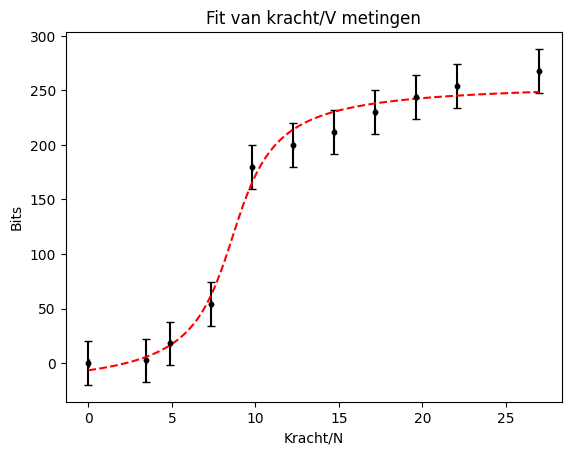

In [7]:
%matplotlib inline
def func(x,a,b,c,d):
    return a*np.arctan(b*x+c)+d

popt,pcov=curve_fit(func,kracht,bits)

x_fit=np.linspace(min(kracht),max(kracht),100)
y_fit=func(x_fit,*popt)

Xerr=0.001*9.81 #weegschaal resolutie
Yerr=20 #varieerde met constante kracht ongeveer +- 20 

plt.errorbar(kracht, bits, xerr=Xerr, yerr=Yerr, fmt='k.', capsize=3, label='Data points')

plt.plot(kracht, bits, 'k.')
plt.plot(x_fit,y_fit, 'r--')
plt.title('Fit van kracht/V metingen')
plt.xlabel('Kracht/N')
plt.ylabel('Bits')
plt.show()


## *Opdracht 7*: Iteratie nodig?

De metingen laten zien dat de sensor niks detecteerd onder de 0.4N, wat goed aan onze criteria voldoet. Daarboven is hij nauwkeurig genoeg, dus hij voldoet aan de kracht-criteria voor een knopje. Boven de 0.4 Detecteerd hij voldoende druk om voor een airpod knopje te werken. Bij het tweede deel van ons onderzoek of de sensor aan de criteria voldoet, hebben we de sensor even onder water gedompeld. We zagen meteen dat de metingen heel heftig reageerden. De sensor reageert dus sterk op water, wat al niet voldoet aan ons laatste criterium. Bovendien, nadat we de sensor grondig hebben opgedroogd, bleven de metingen torenhoog, rond de 950 byts, wat kortsluiting laat zien in de sensor. 

## *Opdracht 8*: Conclusie, leerdoel

De sensor voldoet niet aan onze criteria. Onze criteria waren dat de sensor bij krachten tussen 0.4 N en 1N reageert, wat de kracht warbij een airpod knop werkt is, maar de sensor is niet gevoelig genoeg om die krachten op te vangen. Verder moest de sensor ook tot IP3 waterdicht zijn, wat niet het geval is, want onder water reageerde de sensor direct door kortsluiting. Het voldoet ook niet aan onze laatste criterium want de foutmarge is ongeveer 20 bits, wat ongeveer met 2N onzekerheid overeenkomt. Dit is hoger dan ons criterium. Deze sensor is dus niet geschikt voor gebruik in airpods/earbuds knopjes. 
Er valt ook op te merken dat onze data helemaal niet met de fit overeenkomt boven de 10N. Dit kan komen door verschillen in hoe de sensor meet vergeleken met de weegschaal. De weegschaal meet loodrechte kracht naar beneden, terwijl de sensor gevoelig is voor buiging en van de druk/contact oppervlak afhangt. Door te drukken met een vinger (waarbij het contact oppervlak varieert met kracht) kunnen er dus verschillen ontstaan tussen de metingen van de sensor en de weegschaal. Het oppervlak van de weegschaal kan ook buigen, wat een hogere sensor meting kan veroorzaken. Het kan ook zijn dat Arctan niet de juiste fit is voor deze data, hij is op het oog gekozen.

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.



In onze opstelling is onze sensor bovenop een weegschaal geplaatst om simultaan een meting van de weegschaal in Kg en een bit meting van de sensor. Dit is via de arduino en IDE software gedaan.

![Alt](meetopstellingGoed.jpg "Meetopstelling")



sensor circuit diagram hier relevant
![Alt](schetsPlanJuist.jpg "schets student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Hall Sensor | Airpod afstand detectie | Moet alleen AirPods detecteren, geen andere apparaten; Moet pas melding geven wanneer de AirPods zich op 0 tot 100 meter van de eigenaar bevinden; Moet minimaal net zo weerbestendig als AirPods zijn. Met verschil merken tussen magnetisch veld van de aarde (50 microtesla), en airpods/digitale apparaten(75microesla).Hij moet dus tussen de 25 en 100 microtesla nauwkeurig kunnen meten (1 microtesla))|
|LDR | Thuisverlichting sensor | Als het buiten donker is, onder 5000 lux, moeten de lichten aan; Verschil weten tussen zonlicht en lamplicht, zodat de lampen aan blijven (tussen 32000 en 5000 lux meten met een nauwkeurigheid van 100 lux.); Waterdicht IP5|
|Force sensor | AirPod sensor | Moet reageren op hele lichte bewegingen: tussen 0.4 en 1 Newton; Moet waterbestendig zijn, zodat het ook met bv natte vingers gebruikt kan worden, IP3 water resistant; Foutmarge reactie moet heel klein zijn, max 0.1N, zodat de AirPod niet reageert als je het apparaat bijvoorbeeld oppakt of per ongeluk aanraakt.|



Groep 43 heeft gekozen voor sensor force sensor. 

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen? 
We gaan de kracht die we op de druksensor uitvoeren steeds veranderen.
2. Over welk bereik ga je deze variabelen veranderen?
We gaan het tussen 0.4N en 5N veranderen.
3. Wat ga je allemaal meten?
We gaan de massa meten met een weegschaal en daarmee de kracht en de bytes. 
Daarna gaan we meten of de sensor überhaupt werkt onder water.
4. Hoeveel metingen ga je doen?
We gaan 5 metingen doen.
5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
We zouden met deze keuzes wel kunnen beantwoorden of het sensor geschikt is. 


De metingen laten zien dat de sensor niks detecteerd onder de 0.4N, wat goed aan onze criteria voldoet. Daarboven is hij nauwkeurig genoeg, dus hij voldoet aan de kracht-criteria voor een knopje. Boven de 0.4 Detecteerd hij voldoende druk om voor een airpod knopje te werken. Bij het tweede deel van ons onderzoek of de sensor aan de criteria voldoet, hebben we de sensor even onder water gedompeld. We zagen meteen dat de metingen heel heftig reageerden. De sensor reageert dus sterk op water, wat al niet voldoet aan ons laatste criterium. Bovendien, nadat we de sensor grondig hebben opgedroogd, bleven de metingen torenhoog, rond de 950 byts, wat kortsluiting laat zien in de sensor. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

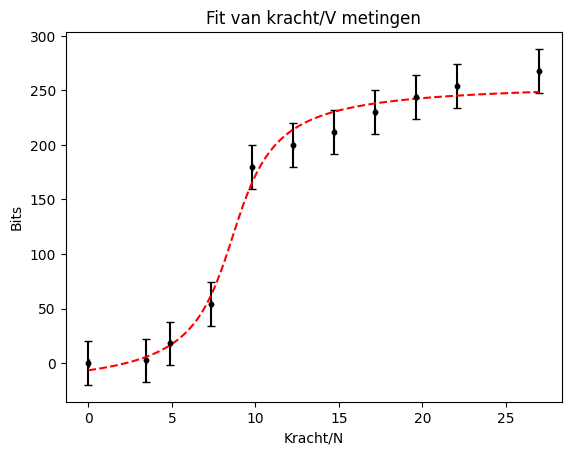

In [8]:
%matplotlib inline
def func(x,a,b,c,d):
    return a*np.arctan(b*x+c)+d

popt,pcov=curve_fit(func,kracht,bits)

x_fit=np.linspace(min(kracht),max(kracht),100)
y_fit=func(x_fit,*popt)

Xerr=0.001*9.81 #weegschaal resolutie
Yerr=20 #varieerde met constante kracht ongeveer +- 20 

plt.errorbar(kracht, bits, xerr=Xerr, yerr=Yerr, fmt='k.', capsize=3, label='Data points')

plt.plot(kracht, bits, 'k.')
plt.plot(x_fit,y_fit, 'r--')
plt.title('Fit van kracht/V metingen')
plt.xlabel('Kracht/N')
plt.ylabel('Bits')
plt.show()




In onze opstelling is onze sensor bovenop een weegschaal geplaatst om simultaan een meting van de weegschaal in Kg en een bit meting van de sensor. Dit is via de arduino en IDE software gedaan.

![Alt](meetopstellingGoed.jpg "Meetopstelling")

Conclusie

De sensor voldoet niet aan onze criteria. Onze criteria waren dat de sensor bij krachten tussen 0.4 N en 1N reageert, wat de kracht warbij een airpod knop werkt is, maar de sensor is niet gevoelig genoeg om die krachten op te vangen. Verder moest de sensor ook tot IP3 waterdicht zijn, wat niet het geval is, want onder water reageerde de sensor direct door kortsluiting. Het voldoet ook niet aan onze laatste criterium want de foutmarge is ongeveer 20 bits, wat ongeveer met 2N onzekerheid overeenkomt. Dit is hoger dan ons criterium. Deze sensor is dus niet geschikt voor gebruik in airpods/earbuds knopjes. 
Er valt ook op te merken dat onze data helemaal niet met de fit overeenkomt boven de 10N. Dit kan komen door verschillen in hoe de sensor meet vergeleken met de weegschaal. De weegschaal meet loodrechte kracht naar beneden, terwijl de sensor gevoelig is voor buiging en van de druk/contact oppervlak afhangt. Door te drukken met een vinger (waarbij het contact oppervlak varieert met kracht) kunnen er dus verschillen ontstaan tussen de metingen van de sensor en de weegschaal. Het oppervlak van de weegschaal kan ook buigen, wat een hogere sensor meting kan veroorzaken. Het kan ook zijn dat Arctan niet de juiste fit is voor deze data, hij is op het oog gekozen.